# IMC Prosperity 4: Round 3 Analysis Engine
This notebook ingests historical market data and parses the platform's standard `log.json` output to reconstruct algorithmic trading performance. 

**Core Functionality:**
1. Stitches multi-day data into a single `continuous_time` index.
2. Extracts Mark-to-Market PnL from the `activitiesLog` payload.
3. Reverse-engineers exact tick-by-tick inventory positions mathematically (bypassing truncated engine logs).

In [1]:
import json
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="darkgrid")

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
data_dir = Path("../datasets/round3")
logs_dir = Path("../logs/r3")
target_submission = 'best' # Change this to analyze different log folders
target_asset = 'VELVETFRUIT_EXTRACT'

# ==========================================
# 2. HISTORICAL MARKET DATA INGESTION
# ==========================================
# AI CONTEXT: Prosperity days consist of 1,000,000 timestamps. 
# To chart multi-day trends, we create a `continuous_time` column: timestamp + (day * 1,000,000)

prices_d0 = pd.read_csv(data_dir / 'prices_round_3_day_0.csv', sep=';')
prices_d1 = pd.read_csv(data_dir / 'prices_round_3_day_1.csv', sep=';')
prices_d2 = pd.read_csv(data_dir / 'prices_round_3_day_2.csv', sep=';')

def make_continuous(df):
    """Maps daily timestamps to a single linear timeline."""
    df['continuous_time'] = df['timestamp'] + (df['day'] * 1000000)
    return df

prices = pd.concat([
    make_continuous(prices_d0), 
    make_continuous(prices_d1), 
    make_continuous(prices_d2)
]).sort_values('continuous_time').reset_index(drop=True)

print(f"Market Data Loaded: {len(prices)} total ticks across all days.")

Market Data Loaded: 360000 total ticks across all days.


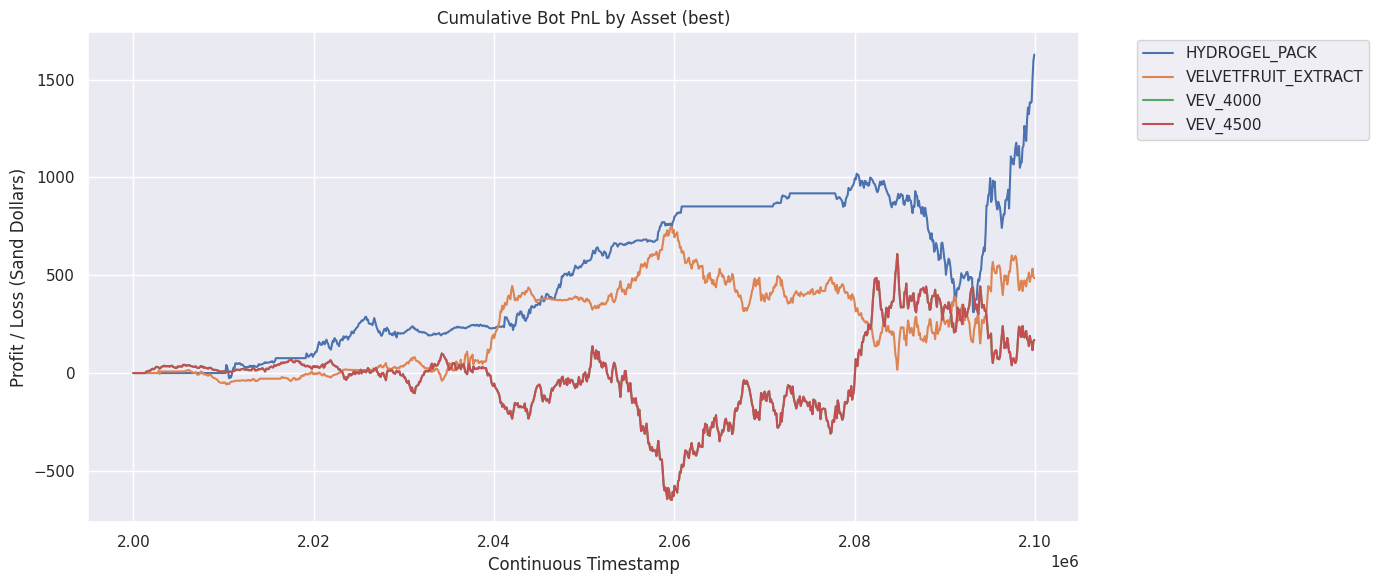

Final PnL Contribution by Asset:
product
HYDROGEL_PACK          1628.531250
VELVETFRUIT_EXTRACT     485.140625
VEV_4500                169.095703
VEV_4000                169.093750
VEV_5000                  0.000000
VEV_5100                  0.000000
VEV_5200                  0.000000
VEV_5300                  0.000000
VEV_5400                  0.000000
VEV_5500                  0.000000
VEV_6000                  0.000000
VEV_6500                  0.000000
Name: 2099900, dtype: float64


In [2]:
# ==========================================
# 3. SUBMISSION LOG PARSING (activitiesLog)
# ==========================================
# AI CONTEXT: The Prosperity engine often truncates the 'trades' and 'sandboxLogs' 
# arrays in `log.json` due to file size limits. However, the 'activitiesLog' (a CSV 
# embedded as a string inside the JSON) is always intact. It contains tick-by-tick 
# mid_price and profit_and_loss for the bot.

log_file_path = logs_dir / target_submission / 'log.json'

with open(log_file_path, 'r') as f:
    submission_data = json.load(f)

# Extract and parse the embedded CSV
activities_csv = submission_data.get('activitiesLog', '')
bot_log = pd.read_csv(io.StringIO(activities_csv), sep=';')
bot_log['continuous_time'] = bot_log['timestamp'] + (bot_log['day'] * 1000000)

# ==========================================
# 4. OVERALL PnL CHARTING
# ==========================================
# Pivot to get a clean timeline of PnL for every traded product
pnl_data = bot_log.pivot(index='continuous_time', columns='product', values='profit_and_loss')
pnl_data = pnl_data.ffill().fillna(0)

plt.figure(figsize=(14, 6))
for col in pnl_data.columns:
    # Only plot assets that actually generated PnL to keep the chart clean
    if pnl_data[col].iloc[-1] != 0 or pnl_data[col].min() < 0:
        plt.plot(pnl_data.index, pnl_data[col], label=col, linewidth=1.5)

plt.title(f'Cumulative Bot PnL by Asset ({target_submission})')
plt.xlabel('Continuous Timestamp')
plt.ylabel('Profit / Loss (Sand Dollars)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Final PnL Contribution by Asset:")
print(pnl_data.iloc[-1].sort_values(ascending=False))

In [3]:
# ==========================================
# 5. INVENTORY RECONSTRUCTION ENGINE
# ==========================================
# AI CONTEXT: Because the explicit 'positions' tracking is missing from the JSON, 
# we mathematically reverse-engineer the bot's exact inventory.
# MTM PnL Formula: PnL = Cash + (Position * MidPrice)
# Finite Difference: ΔPnL ≈ Position * ΔMidPrice  ==>  Position = round(ΔPnL / ΔMidPrice)

# Isolate the target asset's timeline
target_df = bot_log[bot_log['product'] == target_asset].set_index('continuous_time')[['mid_price', 'profit_and_loss']].copy()

# Calculate tick-to-tick differences
target_df['delta_pnl'] = target_df['profit_and_loss'].diff()
target_df['delta_mid'] = target_df['mid_price'].diff()

# Derive position (only mathematically valid on ticks where the mid_price actually moved)
target_df['implied_position'] = np.where(
    abs(target_df['delta_mid']) > 0,
    (target_df['delta_pnl'] / target_df['delta_mid']).round(),
    np.nan
)

# Forward-fill the implied positions to bridge the gaps where the price held steady
target_df['position'] = target_df['implied_position'].ffill().fillna(0)

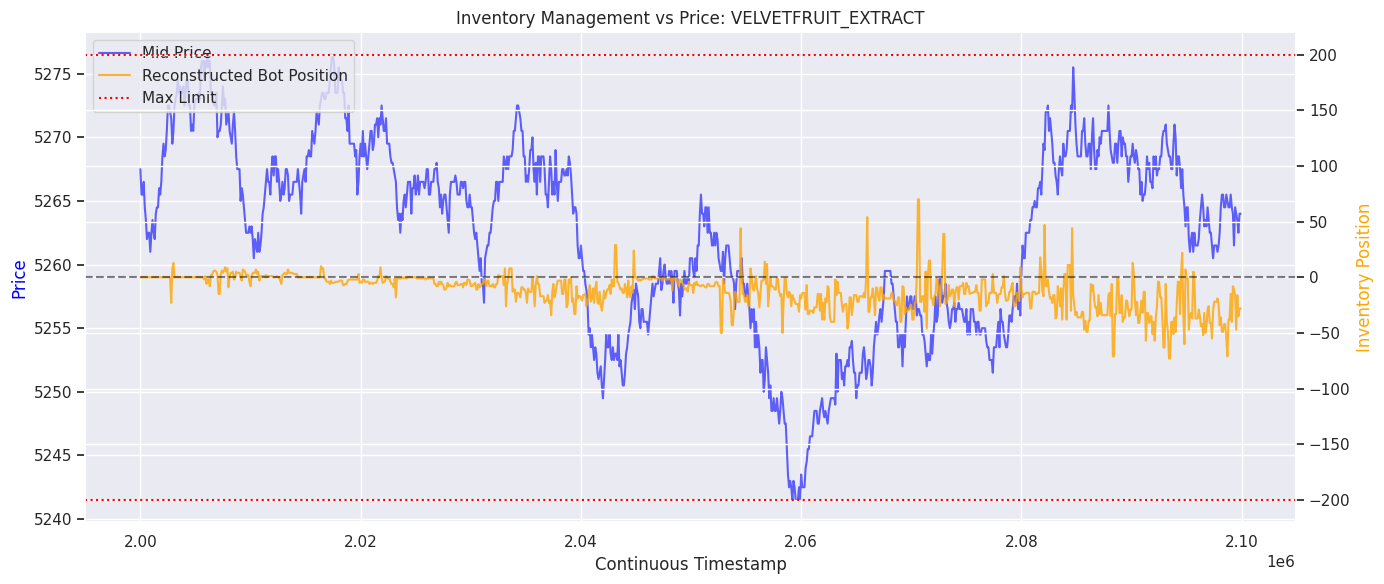

In [4]:
# ==========================================
# 6. INVENTORY SKEW vs. PRICE CHARTING
# ==========================================
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# Plot Mid Price (Left Axis)
ax1.plot(target_df.index, target_df['mid_price'], color='blue', label='Mid Price', alpha=0.6)

# Plot Reconstructed Inventory (Right Axis)
ax2.plot(target_df.index, target_df['position'], color='orange', label='Reconstructed Bot Position', alpha=0.8)

# AI CONTEXT: Asset limits are hardcoded here for visual constraints. 
# VELVETFRUIT_EXTRACT and HYDROGEL_PACK = 200. VEV Options = 300.
limit = 200 
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.axhline(limit, color='red', linestyle=':', label='Max Limit')
ax2.axhline(-limit, color='red', linestyle=':')

# Formatting
ax1.set_xlabel('Continuous Timestamp')
ax1.set_ylabel('Price', color='blue')
ax2.set_ylabel('Inventory Position', color='orange')
plt.title(f'Inventory Management vs Price: {target_asset}')

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()

In [5]:
# --- MICROPRICE ALPHA VERIFICATION ---
df_mp = prices[prices['product'] == 'HYDROGEL_PACK'].copy().set_index('continuous_time')

df_mp['bid_vol'] = df_mp['bid_volume_1'].abs()
df_mp['ask_vol'] = df_mp['ask_volume_1'].abs()
df_mp['total_vol'] = df_mp['bid_vol'] + df_mp['ask_vol']

# Your sub_3.py microprice logic
df_mp['microprice'] = np.where(df_mp['total_vol'] > 0, 
                               (df_mp['bid_price_1'] * df_mp['ask_vol'] + df_mp['ask_price_1'] * df_mp['bid_vol']) / df_mp['total_vol'],
                               df_mp['mid_price'])

df_mp['micro_deviation'] = df_mp['microprice'] - df_mp['mid_price']
df_mp['future_mid_change'] = df_mp['mid_price'].shift(-5) - df_mp['mid_price'] # Look 5 ticks ahead

correlation = df_mp['micro_deviation'].corr(df_mp['future_mid_change'])
print(f"Alpha Correlation (Microprice vs 5-Tick Future Move): {correlation:.4f}")

Alpha Correlation (Microprice vs 5-Tick Future Move): 0.1372


In [6]:
# ==========================================
# 7. QUANTITATIVE METRICS ENGINE (TEXT OUTPUT)
# ==========================================
# Calculates hard metrics to avoid chart misinterpretation:
# - Final PnL
# - Max Drawdown
# - Trade Volume (implied)
# - % Time at Position Limits (Pinning Diagnosis)

metrics_list = []

for product in bot_log['product'].unique():
    prod_df = bot_log[bot_log['product'] == product].sort_values('continuous_time').copy()
    
    # 1. PnL Metrics
    final_pnl = prod_df['profit_and_loss'].iloc[-1]
    if final_pnl == 0 and prod_df['profit_and_loss'].max() == 0 and prod_df['profit_and_loss'].min() == 0:
        continue # Skip entirely flat/untraded assets
        
    max_pnl = prod_df['profit_and_loss'].max()
    min_pnl = prod_df['profit_and_loss'].min()
    
    # Max Drawdown calculation
    rolling_max = prod_df['profit_and_loss'].cummax()
    drawdown = rolling_max - prod_df['profit_and_loss']
    max_drawdown = drawdown.max()
    
    # 2. Position & Pinning Metrics (via Finite Difference)
    prod_df['delta_pnl'] = prod_df['profit_and_loss'].diff()
    prod_df['delta_mid'] = prod_df['mid_price'].diff()
    
    prod_df['implied_position'] = np.where(
        abs(prod_df['delta_mid']) > 0,
        (prod_df['delta_pnl'] / prod_df['delta_mid']).round(),
        np.nan
    )
    prod_df['position'] = prod_df['implied_position'].ffill().fillna(0)
    
    # Determine the asset's limit (300 for VEV options, 200 for Spot)
    pos_limit = 300 if 'VEV' in product else 200
    
    # Calculate percentage of time the bot spent pinned at its maximum limit
    time_pinned_pct = ((prod_df['position'] >= pos_limit) | (prod_df['position'] <= -pos_limit)).mean() * 100
    
    # 3. Implied Volume
    prod_df['trade_volume'] = prod_df['position'].diff().abs()
    total_volume = prod_df['trade_volume'].sum()
    
    metrics_list.append({
        'Product': product,
        'Final PnL': round(final_pnl, 2),
        'Max Drawdown': round(max_drawdown, 2),
        'Total Vol': int(total_volume) if pd.notna(total_volume) else 0,
        '% Time Pinned': round(time_pinned_pct, 2)
    })

# Format and print the final table
if metrics_list:
    metrics_df = pd.DataFrame(metrics_list).sort_values('Final PnL', ascending=False)
    print("=" * 65)
    print(f"{'QUANTITATIVE PERFORMANCE SUMMARY':^65}")
    print("=" * 65)
    print(metrics_df.to_string(index=False))
    print("=" * 65)
else:
    print("No trading activity detected for any asset.")

                QUANTITATIVE PERFORMANCE SUMMARY                 
            Product  Final PnL  Max Drawdown  Total Vol  % Time Pinned
      HYDROGEL_PACK    1628.53        707.80       2436            0.0
VELVETFRUIT_EXTRACT     485.14        730.88       6946            0.0
           VEV_4500     169.10        786.12       6576            0.0
           VEV_4000     169.09        786.12       6187            0.0


In [7]:
from sklearn.linear_model import LinearRegression

# ==========================================
# 8. ADVANCED STABILITY & RISK METRICS
# ==========================================
# AI CONTEXT: Standard Sharpe/Sortino ratios assume normal distribution. 
# We add 'Stability (R²)' to identify strategies that "die" or "stall".
# H1/H2 PnL identifies strategies that lose edge halfway through.

advanced_metrics = []

for product in bot_log['product'].unique():
    prod_df = bot_log[bot_log['product'] == product].sort_values('continuous_time').copy()
    pnl = prod_df['profit_and_loss'].values
    
    if pnl[-1] == 0 and pnl.max() == 0: continue

    # 1. Returns for Sharpe/Sortino
    returns = np.diff(pnl)
    downside_returns = returns[returns < 0]
    
    mean_ret = np.mean(returns)
    std_ret = np.std(returns)
    sortino_std = np.std(downside_returns) if len(downside_returns) > 0 else 1e-6
    
    sharpe = (mean_ret / std_ret) * np.sqrt(len(returns)) if std_ret > 0 else 0
    sortino = (mean_ret / sortino_std) * np.sqrt(len(returns)) if sortino_std > 0 else 0

    # 2. Stability (R-Squared)
    # Fits a line to PnL. R² near 1.0 means perfect steady growth. 
    # R² near 0 or negative means the strategy is volatile or "died".
    X = np.arange(len(pnl)).reshape(-1, 1)
    y = pnl.reshape(-1, 1)
    reg = LinearRegression().fit(X, y)
    stability = reg.score(X, y)

    # 3. H1 vs H2 Momentum (Halfway split)
    mid_point = len(pnl) // 2
    h1_pnl = pnl[mid_point] - pnl[0]
    h2_pnl = pnl[-1] - pnl[mid_point]
    momentum_drain = (h2_pnl - h1_pnl) # Negative means second half was worse

    advanced_metrics.append({
        'Product': product,
        'Final PnL': round(pnl[-1], 2),
        'Sharpe': round(sharpe, 2),
        'Sortino': round(sortino, 2),
        'Stability (R²)': round(stability, 2),
        'H1 PnL': round(h1_pnl, 2),
        'H2 PnL': round(h2_pnl, 2)
    })

adv_df = pd.DataFrame(advanced_metrics).sort_values('Final PnL', ascending=False)
print("=" * 85)
print(f"{'ADVANCED RISK & STABILITY ANALYSIS':^85}")
print("=" * 85)
print(adv_df.to_string(index=False))
print("=" * 85)

                         ADVANCED RISK & STABILITY ANALYSIS                          
            Product  Final PnL  Sharpe  Sortino  Stability (R²)  H1 PnL  H2 PnL
      HYDROGEL_PACK    1628.53    2.51     2.79            0.81  576.80 1051.73
VELVETFRUIT_EXTRACT     485.14    0.78     0.97            0.51  367.70  117.44
           VEV_4500     169.10    0.21     0.29            0.03   -6.46  175.55
           VEV_4000     169.09    0.21     0.29            0.03   -6.46  175.55


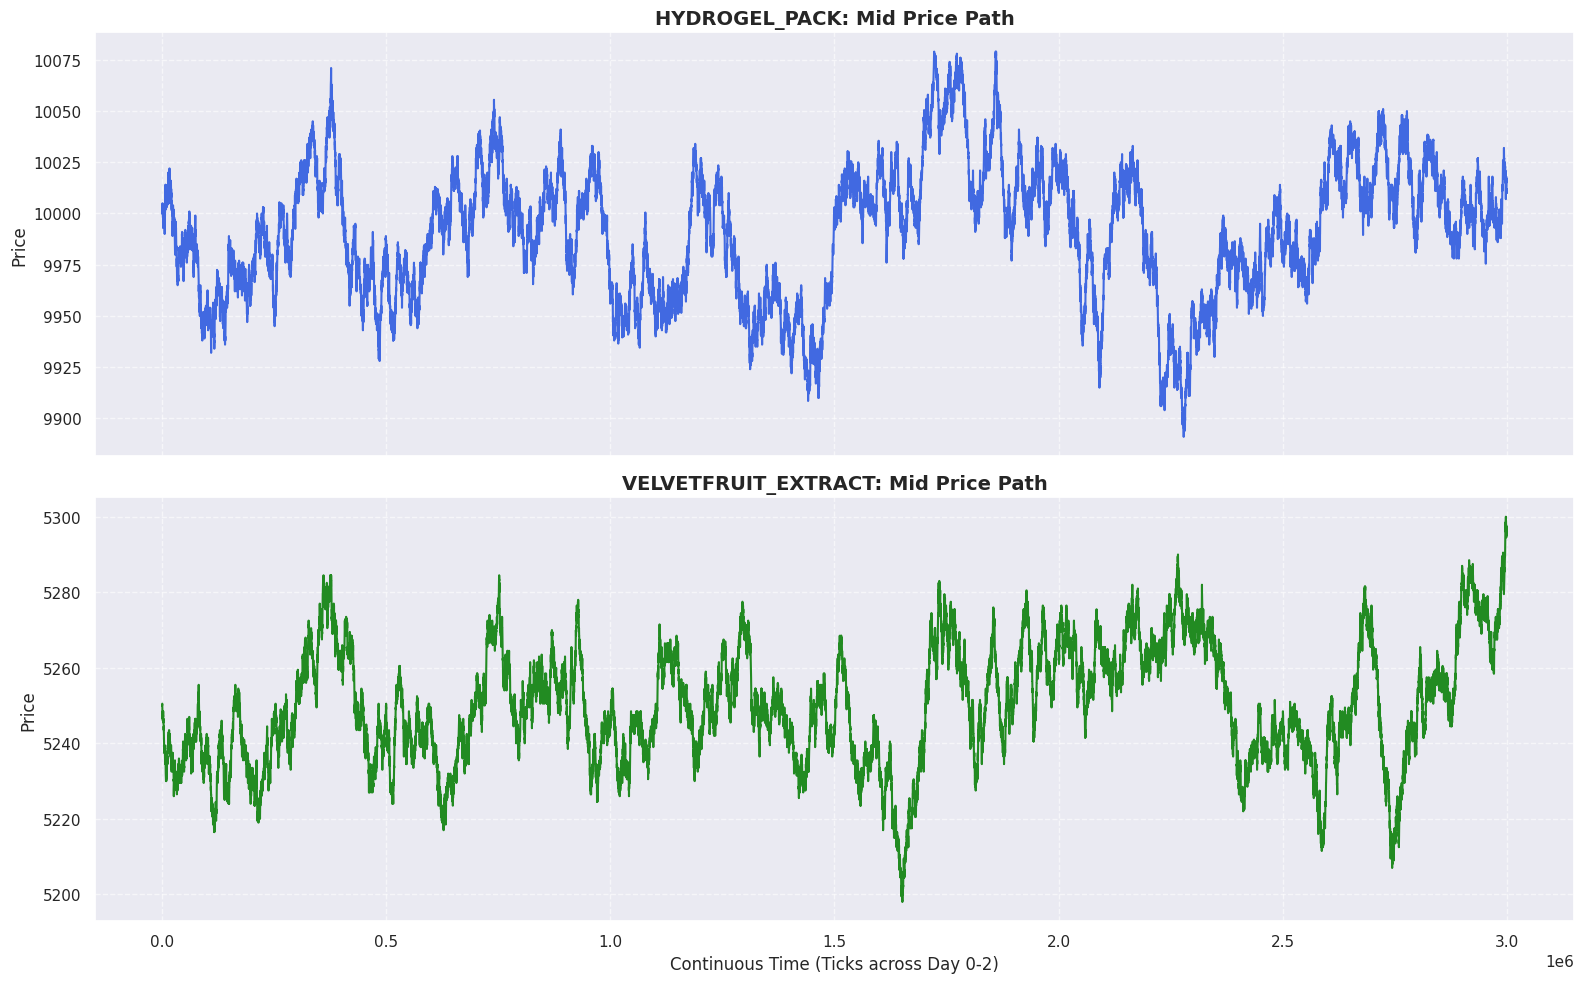

In [8]:
# ==========================================
# 3. UNDERLYING PRICE PATHS
# ==========================================
# Filter data for our two main underlying products
hydrogel = prices[prices['product'] == 'HYDROGEL_PACK']
velvetfruit = prices[prices['product'] == 'VELVETFRUIT_EXTRACT']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Plot Hydrogel
ax1.plot(hydrogel['continuous_time'], hydrogel['mid_price'], color='royalblue', linewidth=1.5)
ax1.set_title('HYDROGEL_PACK: Mid Price Path', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Velvetfruit
ax2.plot(velvetfruit['continuous_time'], velvetfruit['mid_price'], color='forestgreen', linewidth=1.5)
ax2.set_title('VELVETFRUIT_EXTRACT: Mid Price Path', fontsize=14, fontweight='bold')
ax2.set_xlabel('Continuous Time (Ticks across Day 0-2)', fontsize=12)
ax2.set_ylabel('Price', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


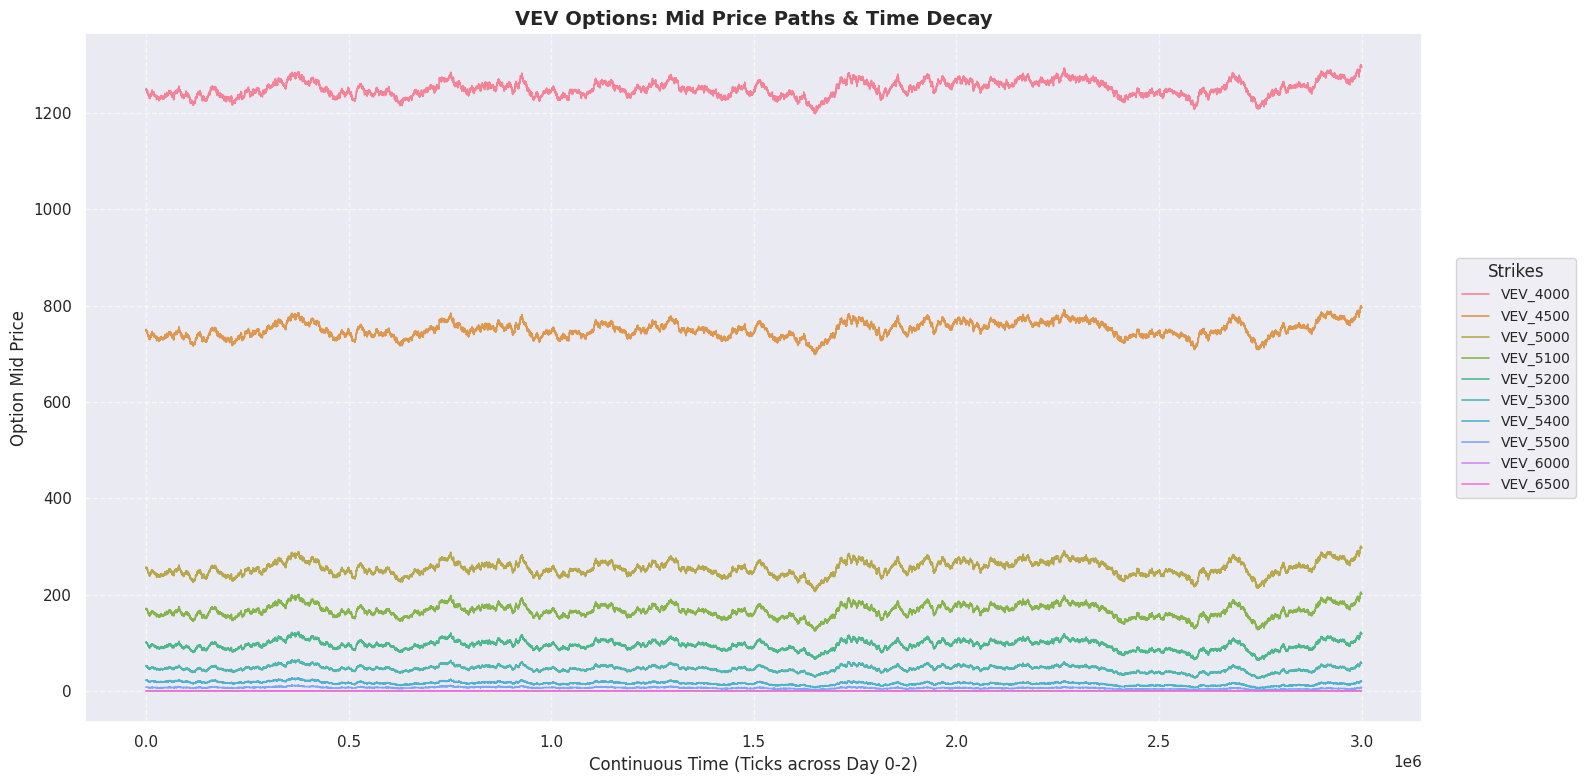

In [9]:
# ==========================================
# 4. OPTIONS PRICE PATHS (VEV STRIKES)
# ==========================================
# Identify all option symbols dynamically
vev_products = sorted([p for p in prices['product'].unique() if p.startswith('VEV_')])

fig, ax = plt.subplots(figsize=(16, 8))

# Use a colormap to visually separate the strikes
colors = sns.color_palette("husl", len(vev_products))

for idx, product in enumerate(vev_products):
    option_data = prices[prices['product'] == product]
    ax.plot(
        option_data['continuous_time'], 
        option_data['mid_price'], 
        label=product, 
        color=colors[idx], 
        linewidth=1.2,
        alpha=0.85
    )

ax.set_title('VEV Options: Mid Price Paths & Time Decay', fontsize=14, fontweight='bold')
ax.set_xlabel('Continuous Time (Ticks across Day 0-2)', fontsize=12)
ax.set_ylabel('Option Mid Price', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# Move legend outside the plot so it doesn't cover the data
ax.legend(title="Strikes", loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# 5. TEXT-BASED STATISTICAL SUMMARY FOR AI
# ==========================================
import pandas as pd
import numpy as np

print("=========================================================")
print("               MARKET REGIME TEXT SUMMARY                ")
print("=========================================================")

# 1. Analyze Underlying Assets
for prod in ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']:
    df = prices[prices['product'] == prod].copy()
    if df.empty: 
        continue
    
    start_p = df['mid_price'].iloc[0]
    end_p = df['mid_price'].iloc[-1]
    min_p = df['mid_price'].min()
    max_p = df['mid_price'].max()
    
    # Calculate tick-to-tick changes
    diffs = df['mid_price'].diff().dropna()
    max_jump = diffs.max()
    max_drop = diffs.min()
    std_dev = df['mid_price'].std()
    
    print(f"[{prod}]")
    print(f"  Path  : Start={start_p:.2f} -> End={end_p:.2f} (Net: {end_p - start_p:+.2f})")
    print(f"  Range : Min={min_p:.2f} | Max={max_p:.2f} | Total Spread={max_p - min_p:.2f}")
    print(f"  Shocks: Max 1-Tick Jump={max_jump:+.2f} | Max 1-Tick Drop={max_drop:+.2f}")
    print(f"  Vol   : StdDev={std_dev:.2f}")
    print("-" * 57)

# 2. Analyze Options (VEV strikes)
vev_products = sorted([p for p in prices['product'].unique() if p.startswith('VEV_')])
print("[VEV OPTIONS SUMMARY]")
print(f"  {'Product':<10} | {'Start':>7} | {'End':>7} | {'Min':>7} | {'Max':>7} | {'Net Change':>10}")

for prod in vev_products:
    df = prices[prices['product'] == prod]
    if df.empty: 
        continue
    
    start_p = df['mid_price'].iloc[0]
    end_p = df['mid_price'].iloc[-1]
    min_p = df['mid_price'].min()
    max_p = df['mid_price'].max()
    net_change = end_p - start_p
    
    print(f"  {prod:<10} | {start_p:>7.2f} | {end_p:>7.2f} | {min_p:>7.2f} | {max_p:>7.2f} | {net_change:>+10.2f}")

print("=========================================================")

               MARKET REGIME TEXT SUMMARY                
[HYDROGEL_PACK]
  Path  : Start=10000.00 -> End=10010.00 (Net: +10.00)
  Range : Min=9891.00 | Max=10079.00 | Total Spread=188.00
  Shocks: Max 1-Tick Jump=+11.50 | Max 1-Tick Drop=-11.50
  Vol   : StdDev=31.94
---------------------------------------------------------
[VELVETFRUIT_EXTRACT]
  Path  : Start=5250.00 -> End=5295.50 (Net: +45.50)
  Range : Min=5198.00 | Max=5300.00 | Total Spread=102.00
  Shocks: Max 1-Tick Jump=+5.00 | Max 1-Tick Drop=-5.50
  Vol   : StdDev=15.63
---------------------------------------------------------
[VEV OPTIONS SUMMARY]
  Product    |   Start |     End |     Min |     Max | Net Change
  VEV_4000   | 1250.00 | 1295.00 | 1198.00 | 1300.00 |     +45.00
  VEV_4500   |  750.00 |  795.50 |  698.50 |  799.50 |     +45.50
  VEV_5000   |  257.00 |  296.50 |  206.50 |  300.50 |     +39.50
  VEV_5100   |  171.50 |  201.50 |  125.00 |  205.50 |     +30.00
  VEV_5200   |  101.50 |  119.00 |   64.00 |  122.5